# 04 - Model Comparison and Final Testing

This notebook consolidates outputs from classification and regression notebooks and exports final summary artifacts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
PROJECT_ROOT = Path.cwd().parent
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "comparison"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
clf_metrics = pd.read_csv(TABLE_DIR / "classification_metrics.csv")
reg_metrics = pd.read_csv(TABLE_DIR / "regression_metrics.csv")
clf_baseline = pd.read_csv(TABLE_DIR / "classification_baseline_metrics.csv")
reg_baseline = pd.read_csv(TABLE_DIR / "regression_baseline_metrics.csv")
clf_pred = pd.read_csv(OUTPUT_DIR / "predictions" / "classification_predictions.csv")
reg_pred = pd.read_csv(OUTPUT_DIR / "predictions" / "regression_predictions.csv")
print("Loaded all artifacts")

Loaded all artifacts


In [3]:
final_summary = pd.DataFrame([
    {
        "task": "classification",
        "primary_metric": "weighted_f1",
        "primary_metric_value": float(clf_metrics.loc[clf_metrics["metric"] == "test_f1_weighted", "value"].iloc[0]),
        "secondary_metric": "accuracy",
        "secondary_metric_value": float(clf_metrics.loc[clf_metrics["metric"] == "test_accuracy", "value"].iloc[0]),
    },
    {
        "task": "regression",
        "primary_metric": "rmse",
        "primary_metric_value": float(reg_metrics.loc[reg_metrics["metric"] == "test_rmse", "value"].iloc[0]),
        "secondary_metric": "r2",
        "secondary_metric_value": float(reg_metrics.loc[reg_metrics["metric"] == "test_r2", "value"].iloc[0]),
    },
])

final_summary.to_csv(TABLE_DIR / "final_task_summary.csv", index=False)
final_summary

,task,primary_metric,primary_metric_value,secondary_metric,secondary_metric_value
0,classification,weighted_f1,0.584685,accuracy,0.592223
1,regression,rmse,0.689013,r2,0.930409


C:\Users\HP\AppData\Local\Temp\ipykernel_23044\2291133427.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="model", y="val_f1_weighted", palette="viridis")


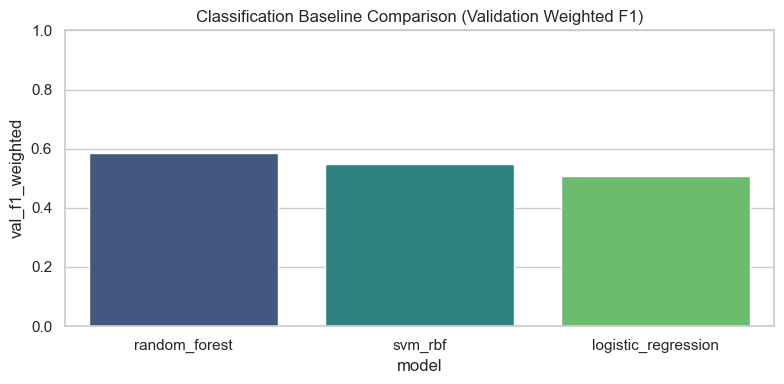

In [4]:
plt.figure(figsize=(8, 4))
plot_df = clf_baseline.sort_values("val_f1_weighted", ascending=False)
sns.barplot(data=plot_df, x="model", y="val_f1_weighted", palette="viridis")
plt.ylim(0, 1)
plt.title("Classification Baseline Comparison (Validation Weighted F1)")
plt.tight_layout()
plt.savefig(FIG_DIR / "classification_baseline_comparison.png", dpi=300)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_23044\1775369574.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="model", y="rmse", palette="magma")


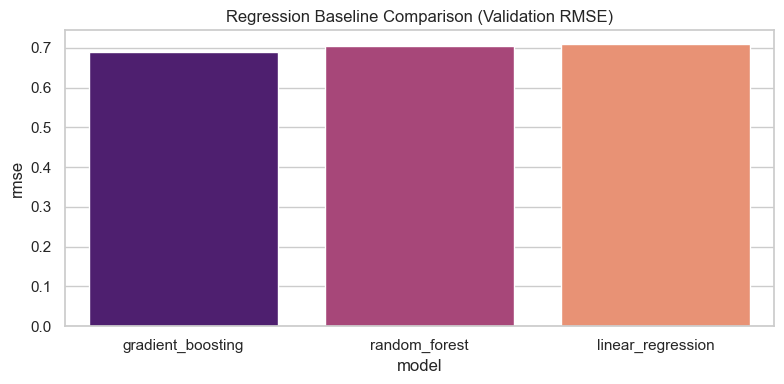

In [5]:
plt.figure(figsize=(8, 4))
plot_df = reg_baseline.sort_values("rmse", ascending=True)
sns.barplot(data=plot_df, x="model", y="rmse", palette="magma")
plt.title("Regression Baseline Comparison (Validation RMSE)")
plt.tight_layout()
plt.savefig(FIG_DIR / "regression_baseline_comparison.png", dpi=300)
plt.show()

In [6]:
extra_checks = pd.DataFrame([
    {"check": "classification_match_rate", "value": float((clf_pred["actual"] == clf_pred["predicted"]).mean())},
    {"check": "regression_mae_from_predictions", "value": float((reg_pred["actual"] - reg_pred["predicted"]).abs().mean())},
])
extra_checks.to_csv(TABLE_DIR / "final_prediction_checks.csv", index=False)
extra_checks

,check,value
0,classification_match_rate,0.592223
1,regression_mae_from_predictions,0.583436
